# Analyze Ising optimization results

This notebook reads the best optimization results from
`data/optimization_results/opt_Ising/` and plots the optimal squeezing parameter `xi`
as a function of the number of layers for different `Rb` and `Omega/Delta` values.

Expected directory structure:

```text
data/optimization_results/opt_Ising/
└── 4x4/
    ├── Rb_1p5/
    │   ├── OmegaDelta_1_2/
    │   │   ├── layers_1/
    │   │   ├── layers_2/
    │   │   └── ...
    │   ├── OmegaDelta_1_3/
    │   └── OmegaDelta_1_10/
    ├── Rb_2/
    └── Rb_2p5/
```

Each optimization JSON file is assumed to contain
`{"parameters": [...], "xi": ...}`.


In [9]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def dB(x):

    return 10 * np.log10(x)

## Locate the result directory

Run the notebook from the project root. If the notebook itself is stored elsewhere,
change `PROJECT_ROOT` below.


In [2]:
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "data" / "optimization_results" / "opt_Ising"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"Could not find results directory: {RESULTS_DIR}")


Project root: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising
Results directory: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_Ising


## Read all layer results

If more than one JSON file is present inside a layer directory, this keeps the file with
the smallest `xi`.


In [3]:
def parse_rb(name):
    # Rb_1p5 -> 1.5, Rb_2 -> 2.0
    value = name.removeprefix("Rb_").replace("p", ".")
    return float(value)


def parse_omega_delta(name):
    # OmegaDelta_1_2 -> numerator=1, denominator=2, ratio=0.5
    match = re.fullmatch(r"OmegaDelta_(\d+)_(\d+)", name)
    if match is None:
        raise ValueError(f"Could not parse Omega/Delta folder name: {name}")
    numerator = int(match.group(1))
    denominator = int(match.group(2))
    return numerator, denominator, numerator / denominator


def parse_layer(name):
    match = re.fullmatch(r"layers_(\d+)", name)
    if match is None:
        raise ValueError(f"Could not parse layer folder name: {name}")
    return int(match.group(1))


def read_best_json(layer_dir):
    json_files = [p for p in layer_dir.glob("*.json") if not p.name.endswith(".lock")]
    if not json_files:
        return None

    records = []
    for path in json_files:
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        if "xi" not in data or "parameters" not in data:
            continue

        records.append((float(data["xi"]), data["parameters"], path))

    if not records:
        return None

    xi, parameters, path = min(records, key=lambda x: x[0])
    return {
        "xi": xi,
        "parameters": np.asarray(parameters, dtype=float),
        "file": path,
    }


rows = []

for geometry_dir in sorted(RESULTS_DIR.iterdir()):
    if not geometry_dir.is_dir():
        continue

    geometry = geometry_dir.name

    for rb_dir in sorted(geometry_dir.glob("Rb_*")):
        if not rb_dir.is_dir():
            continue
        rb = parse_rb(rb_dir.name)

        for omega_dir in sorted(rb_dir.glob("OmegaDelta_*")):
            if not omega_dir.is_dir():
                continue

            num, den, omega_over_delta = parse_omega_delta(omega_dir.name)

            for layer_dir in sorted(omega_dir.glob("layers_*")):
                if not layer_dir.is_dir():
                    continue

                n_layers = parse_layer(layer_dir.name)
                best = read_best_json(layer_dir)

                if best is None:
                    continue

                rows.append({
                    "geometry": geometry,
                    "Rb": rb,
                    "omega_num": num,
                    "omega_den": den,
                    "Omega_over_Delta": omega_over_delta,
                    "Omega_over_Delta_label": f"{num}/{den}",
                    "layers": n_layers,
                    "xi": best["xi"],
                    "parameters": best["parameters"],
                    "file": str(best["file"]),
                })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError("No optimization JSON files were found in layer directories.")

df = df.sort_values(["geometry", "Rb", "Omega_over_Delta", "layers"]).reset_index(drop=True)
df


,geometry,Rb,omega_num,omega_den,Omega_over_Delta,Omega_over_Delta_label,layers,xi,parameters,file
0,4x4,1.5,1,10,0.100000,1/10,1,0.704738,"[30000.0, 5853.659309905587]",/Users/raka3858/PycharmProjects/PythonProject/...
1,4x4,1.5,1,10,0.100000,1/10,2,0.577112,"[30000.0, 30000.0, 0.06605869294174166, 30000....",/Users/raka3858/PycharmProjects/PythonProject/...
2,4x4,1.5,1,10,0.100000,1/10,3,0.507740,"[30000.0, 30000.0, 0.20374064573796044, 30000....",/Users/raka3858/PycharmProjects/PythonProject/...
3,4x4,1.5,1,3,0.333333,1/3,1,0.621900,"[721.70935684332, 109.86638985664948]",/Users/raka3858/PycharmProjects/PythonProject/...
4,4x4,1.5,1,3,0.333333,1/3,2,0.516761,"[712.9090745240227, 485.5404092768213, 0.60660...",/Users/raka3858/PycharmProjects/PythonProject/...
5,4x4,1.5,1,3,0.333333,1/3,3,0.459929,"[617.0889409510821, 467.64516710158824, 0.5577...",/Users/raka3858/PycharmProjects/PythonProject/...
6,4x4,1.5,1,2,0.500000,1/2,1,0.624327,"[205.4871574496073, 32.50508070291688]",/Users/raka3858/PycharmProjects/PythonProject/...
7,4x4,1.5,1,2,0.500000,1/2,2,0.526005,"[191.08749440177084, 127.16095203168044, 0.590...",/Users/raka3858/PycharmProjects/PythonProject/...
8,4x4,1.5,1,2,0.500000,1/2,3,0.525979,"[41.900303266104984, 418.65214350874635, 3.141...",/Users/raka3858/PycharmProjects/PythonProject/...
9,4x4,1.5,1,2,0.500000,1/2,4,0.583266,"[46.10392455996464, 81.25985219021287, 3.14159...",/Users/raka3858/PycharmProjects/PythonProject/...


## Compact table of optimal values


In [4]:
display_cols = [
    "geometry",
    "Rb",
    "Omega_over_Delta_label",
    "layers",
    "xi",
]

df[display_cols]


,geometry,Rb,Omega_over_Delta_label,layers,xi
0,4x4,1.5,1/10,1,0.704738
1,4x4,1.5,1/10,2,0.577112
2,4x4,1.5,1/10,3,0.507740
3,4x4,1.5,1/3,1,0.621900
4,4x4,1.5,1/3,2,0.516761
5,4x4,1.5,1/3,3,0.459929
6,4x4,1.5,1/2,1,0.624327
7,4x4,1.5,1/2,2,0.526005
8,4x4,1.5,1/2,3,0.525979
9,4x4,1.5,1/2,4,0.583266


## Plot 1: one figure per $R_b$, lines for different $\Omega/\Delta$


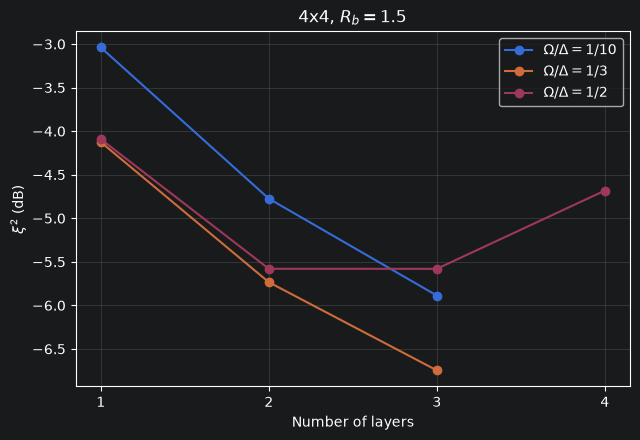

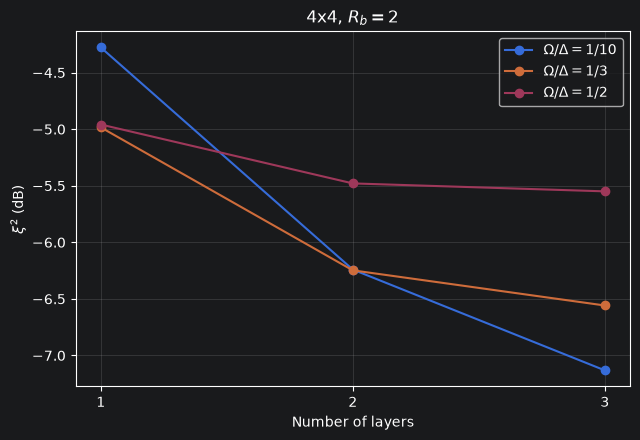

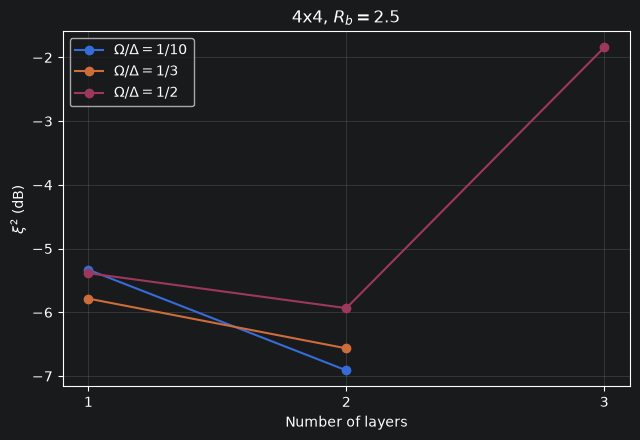

In [10]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    for rb in sorted(df_geom["Rb"].unique()):
        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_rb = df_geom[df_geom["Rb"] == rb]

        for label, group in df_rb.groupby("Omega_over_Delta_label", sort=False):
            group = group.sort_values("layers")
            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$\Omega/\Delta={label}$",
            )

        ax.set_xlabel("Number of layers")
        ax.set_ylabel(r"$\xi^2\ $(dB)")
        ax.set_title(rf"{geometry}, $R_b={rb:g}$")
        ax.set_xticks(sorted(df_rb["layers"].unique()))
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Plot 2: one figure per $\Omega/\Delta$, lines for different $R_b$


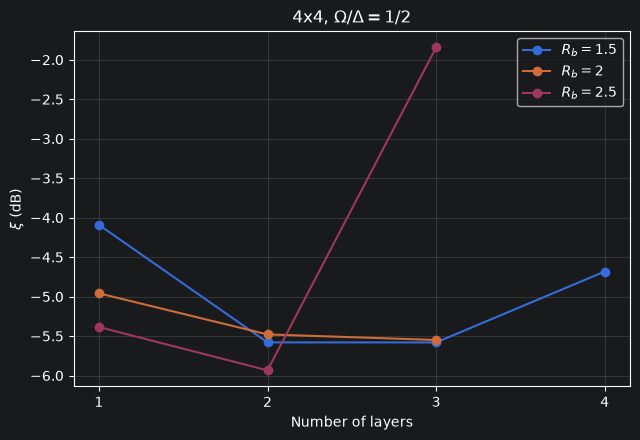

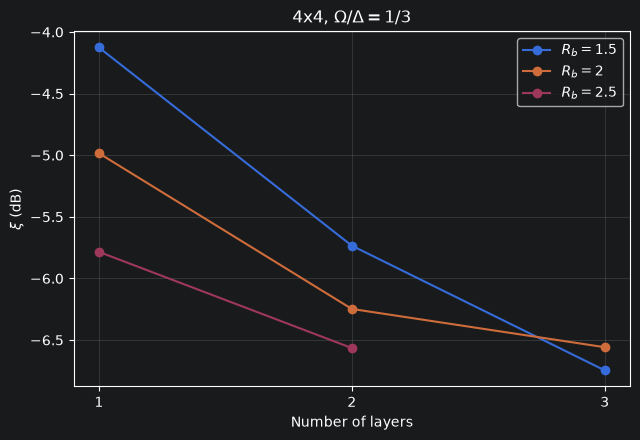

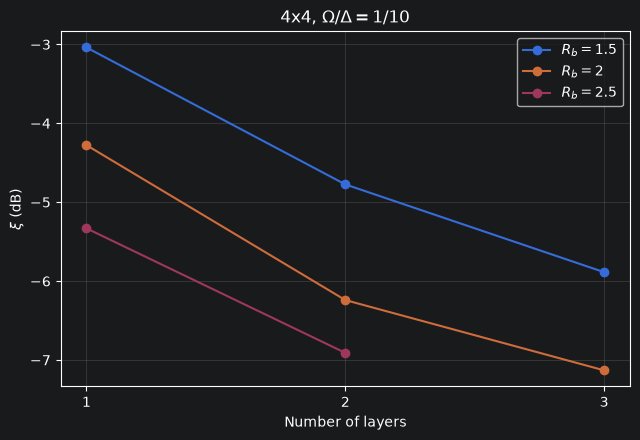

In [11]:
for geometry in sorted(df["geometry"].unique()):
    df_geom = df[df["geometry"] == geometry]

    labels = df_geom[["Omega_over_Delta", "Omega_over_Delta_label"]].drop_duplicates()
    labels = labels.sort_values("Omega_over_Delta", ascending=False)

    for _, row in labels.iterrows():
        ratio = row["Omega_over_Delta"]
        label = row["Omega_over_Delta_label"]

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        df_ratio = df_geom[np.isclose(df_geom["Omega_over_Delta"], ratio)]

        for rb, group in df_ratio.groupby("Rb"):
            group = group.sort_values("layers")
            ax.plot(
                group["layers"],
                dB(group["xi"] ** 2),
                marker="o",
                label=rf"$R_b={rb:g}$",
            )

        ax.set_xlabel("Number of layers")
        ax.set_ylabel(r"$\xi\ $(dB)")
        ax.set_title(rf"{geometry}, $\Omega/\Delta={label}$")
        ax.set_xticks(sorted(df_ratio["layers"].unique()))
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        plt.show()


## Optional: show the optimized gate parameters

This is useful for inspecting the actual sequence parameters for a selected point.


In [7]:
# Example selection
selection = df[
    (df["geometry"] == "4x4")
    & np.isclose(df["Rb"], 1.5)
    & np.isclose(df["Omega_over_Delta"], 0.5)
]

for _, row in selection.sort_values("layers").iterrows():
    print(
        f"layers={row['layers']:d}, "
        f"xi={row['xi']:.8g}, "
        f"parameters={row['parameters']}"
    )


layers=1, xi=0.6243265, parameters=[205.48715745  32.5050807 ]
layers=2, xi=0.52600479, parameters=[191.0874944  127.16095203   0.59009805 167.48858054  50.97869625]
layers=3, xi=0.5259791, parameters=[ 41.90030327 418.65214351   3.14159265 176.24553789  54.67226145
  -1.7465829  272.84580862  33.24108893]
layers=4, xi=0.58326596, parameters=[ 46.10392456  81.25985219   3.14159265   2.66537013 180.3421268
  -1.56217925  53.65664185 139.8620348    3.042906   173.85677968
  27.30029227]


## Optional: save the collected table


In [8]:
# Arrays in the 'parameters' column do not serialize cleanly to CSV, so store them as lists.
df_export = df.copy()
df_export["parameters"] = df_export["parameters"].apply(lambda x: x.tolist())

output_file = RESULTS_DIR / "optimization_summary.csv"
df_export.to_csv(output_file, index=False)
print("Saved:", output_file)


Saved: /Users/raka3858/PycharmProjects/PythonProject/VarOpt_MultiBody_Ising/data/optimization_results/opt_Ising/optimization_summary.csv
